In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

# 2.1 Exercise - 1

### Task 1

In [10]:
# import image
image_path = '/content/drive/MyDrive/Ai final sem/Week 1/image1.png'
image = Image.open(image_path)

# show using display
display(image)

#show using plt
plt.imshow(image)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Task 2

array([[[ 95, 171, 249],
        [ 94, 170, 248],
        [ 96, 169, 246],
        ...,
        [ 99, 171, 247],
        [101, 173, 249],
        [101, 173, 249]],

       [[ 96, 172, 250],
        [ 95, 171, 249],
        [ 96, 170, 245],
        ...,
        [ 98, 170, 246],
        [100, 172, 248],
        [100, 172, 248]],

       [[ 96, 172, 248],
        [ 95, 171, 247],
        [ 96, 170, 245],
        ...,
        [ 99, 170, 250],
        [100, 172, 248],
        [100, 172, 248]],

       ...,

       [[ 88, 162, 235],
        [ 87, 161, 236],
        [ 84, 157, 234],
        ...,
        [ 91, 160, 237],
        [ 89, 161, 237],
        [ 88, 160, 236]],

       [[ 86, 159, 236],
        [ 85, 158, 235],
        [ 82, 155, 234],
        ...,
        [ 87, 159, 235],
        [ 87, 159, 235],
        [ 88, 160, 236]],

       [[ 81, 156, 237],
        [ 81, 156, 237],
        [ 80, 155, 236],
        ...,
        [ 85, 157, 231],
        [ 85, 159, 232],
        [ 87, 161, 234]]], dtype=uint8)
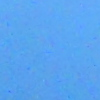

In [12]:
img_array = np.array(image)

top_left = img_array[0:100, 0:100]

display(top_left)

### Task 3

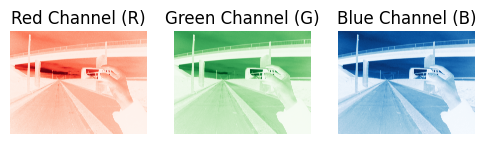

In [13]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(6,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel (R)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel (G)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel (B)")
plt.axis("off")

plt.show()

### Task 4

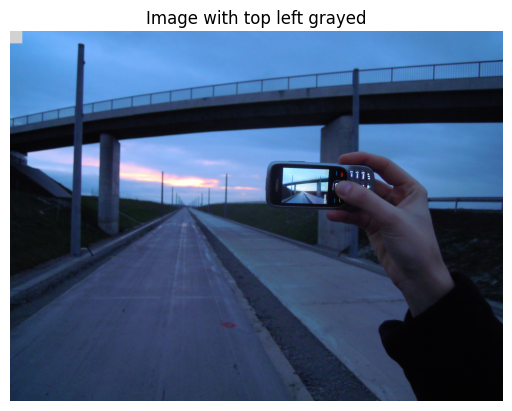

In [14]:
modified_img = img_array.copy()

modified_img[0:100, 0:100] = 210

plt.imshow(modified_img)
plt.title("Image with top left grayed")
plt.axis("off")
plt.show()

# 2.2 Exercise - 2:

### Task 1

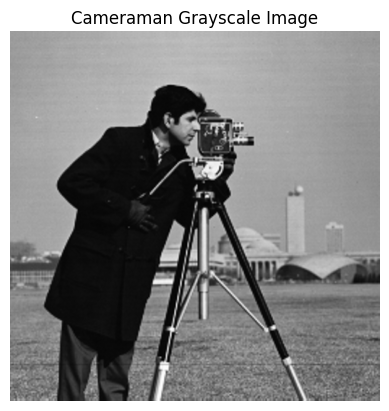

In [15]:
image_path = '/content/drive/MyDrive/Ai final sem/Week 1/cameraman.png'
image = Image.open(image_path)

img_array = np.array(image)

plt.imshow(img_array, cmap='gray')
plt.title("Cameraman Grayscale Image")
plt.axis("off")
plt.show()

### Task 2

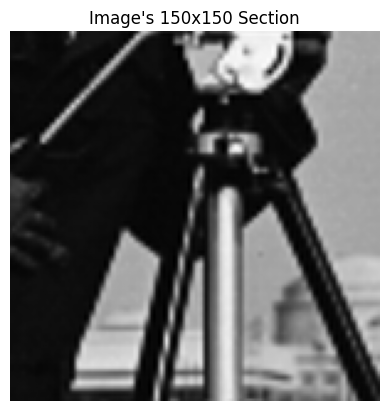

In [16]:
img_array = np.array(image)

height, width = img_array.shape[:2]

center_y = height // 2
center_x = width // 2

half_size = 75
middle_section = img_array[
    center_y - half_size : center_y + half_size,
    center_x - half_size : center_x + half_size
]

plt.imshow(middle_section, cmap='gray')
plt.title("Image's 150x150 Section")
plt.axis("off")
plt.show()

### Task 3

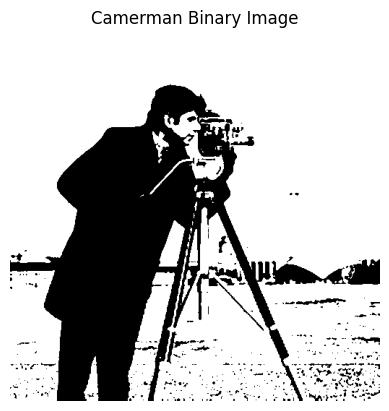

In [17]:
binary_image = np.where(img_array < 100, 0, 255)

plt.imshow(binary_image, cmap='gray')
plt.title("Camerman Binary Image")
plt.axis("off")
plt.show()

### Task 4

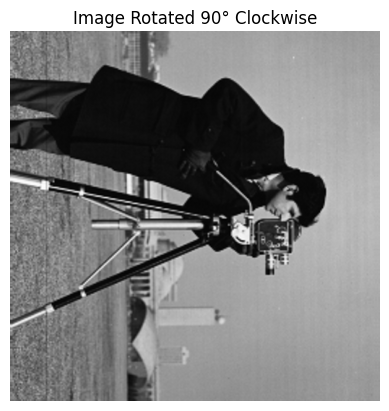

In [18]:
rotated_image = image.rotate(-90)

plt.imshow(rotated_image, cmap='gray')
plt.title("Image Rotated 90° Clockwise")
plt.axis("off")
plt.show()

### Task 5

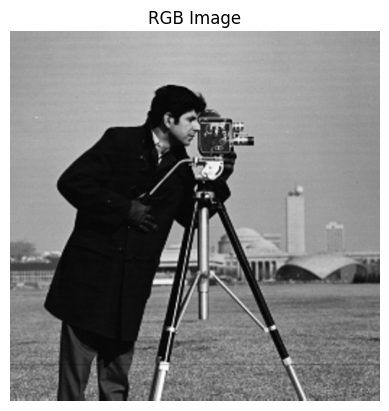

In [19]:
gray_array = np.array(image)

rgb_array = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_array)
plt.title("RGB Image")
plt.axis("off")
plt.show()

# Image Compression and Decompression using PCA

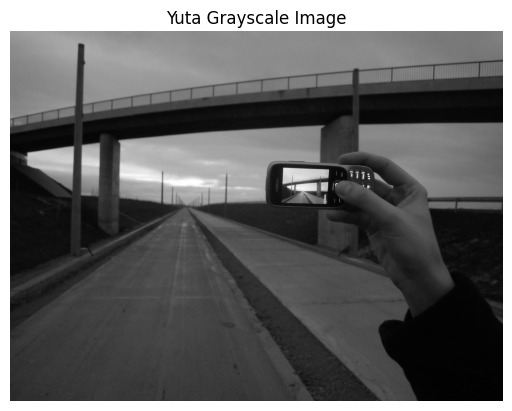

This is [[157. 156. 156. ... 130. 126. 126.]
 [158. 157. 156. ... 129. 129. 129.]
 [158. 157. 156. ... 130. 129. 131.]
 ...
 [ 41.  37.  34. ...   4.   3.   3.]
 [ 42.  37.  36. ...   4.   3.   3.]
 [ 42.  36.  37. ...   3.   3.   3.]]
Mean shape: (4000,)
Centered data shape: (3000, 4000)
Covariance matrix shape: (4000, 4000)
Covariance matrix:
 [[2418.34745404 2413.1095254  2408.4670788  ...  470.96471757
   472.137003    468.1897946 ]
 [2413.1095254  2411.26931199 2407.38443926 ...  470.32204068
   471.51957319  467.55048349]
 [2408.4670788  2407.38443926 2406.38503457 ...  469.45692431
   470.57322574  466.56430744]
 ...
 [ 470.96471757  470.32204068  469.45692431 ... 2061.45456085
  2053.61608269 2048.11310904]
 [ 472.137003    471.51957319  470.57322574 ... 2053.61608269
  2048.06209003 2043.22431344]
 [ 468.1897946   467.55048349  466.56430744 ... 2048.11310904
  2043.22431344 2040.54256652]]


In [20]:
image_path = '/content/drive/MyDrive/Ai final sem/Week 1/image1.png'
image = Image.open(image_path).convert("L")

img_array = np.array(image)
plt.imshow(img_array, cmap='gray')
plt.title("Yuta Grayscale Image")
plt.axis("off")
plt.show()

X = img_array.astype(float)
print("This is",X)

mean = np.mean(X, axis=0)

X_centered = X - mean
print("Mean shape:", mean.shape)
print("Centered data shape:", X_centered.shape)

cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)
print("Covariance matrix:\n", cov_matrix)

In [21]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (4000,)
Eigenvectors shape: (4000, 4000)


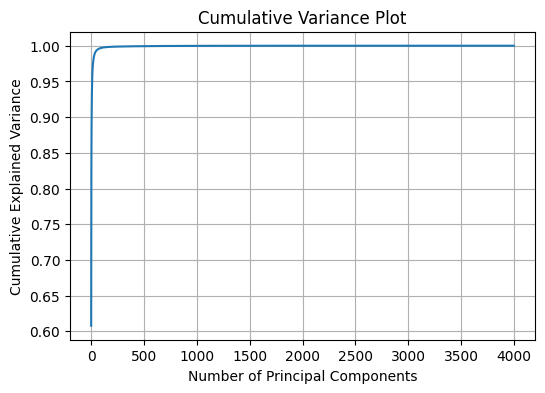

In [22]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.grid()
plt.show()

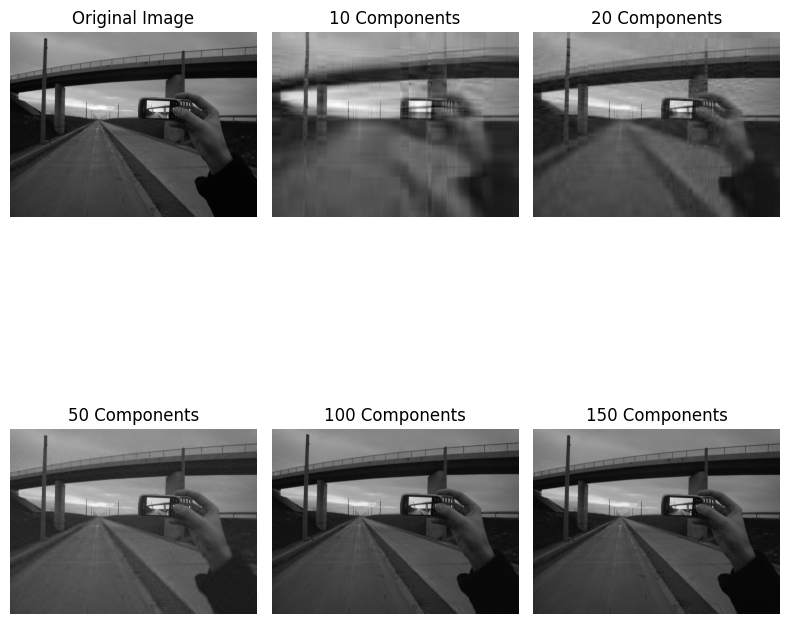

In [23]:
def reconstruct_image(X_centered, eigenvectors, k, mean):
    PCs = eigenvectors[:, :k]

    X_reduced = np.dot(X_centered, PCs)

    X_reconstructed = np.dot(X_reduced, PCs.T) + mean

    return X_reconstructed

k_values = [10, 20, 50, 100, 150]

plt.figure(figsize=(8, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(X_centered, eigenvectors, k, mean)
    plt.subplot(2, 3, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()

At 10-20 components the reconstructed image has many vertical slashes. At 50-100 components the reconstructed image has gotten significantly sharper and better. Though from 100 components onwards the result has not increased by a big margin.